In [4]:
import pandas as pd

fomc_path = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 3- Sentiment Analysis/fomc_cleaned.csv"

fomc = pd.read_csv(fomc_path, parse_dates=["meeting_date"])

print(f"Shape: {fomc.shape}")
print(f"Columns: {fomc.columns.tolist()}")
print(f"Doc types: {fomc['doc_type'].value_counts()}")
print(f"Date range: {fomc['meeting_date'].min()} → {fomc['meeting_date'].max()}")

# Check word counts
fomc["word_count"] = fomc["text"].str.split().str.len()
print(f"\nWord counts by doc type:")
print(fomc.groupby("doc_type")["word_count"].describe().round(0))

Shape: (146, 6)
Columns: ['meeting_date', 'doc_type', 'url', 'text', 'text_clean', 'word_count']
Doc types: doc_type
statement    74
minutes      72
Name: count, dtype: int64
Date range: 2016-01-27 00:00:00 → 2025-12-10 00:00:00

Word counts by doc type:
           count    mean     std     min     25%     50%     75%      max
doc_type                                                                 
minutes     72.0  8634.0  1785.0  6395.0  7353.0  8326.0  9076.0  14176.0
statement   74.0   468.0    99.0   256.0   397.0   430.0   550.0    763.0


In [5]:
import requests
import io

#download the Loughran-McDonald dictionary

url = ("https://drive.google.com/uc?export=download"
       "&id=12ECPJMxV2wSalXG8ykMmkpa1fq_ur0Rf")

try:
    r = requests.get(url)
    lm_dict = pd.read_csv(io.StringIO(r.text))
    print("Downloaded LM dictionary from web")
except Exception:
    # If download fails, place the CSV in your Section 3 folder
    lm_path = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 3- Sentiment Analysis/LoughranMcDonald_MasterDictionary.csv"
    lm_dict = pd.read_csv(lm_path)
    print("Loaded LM dictionary from local file")

print(f"Dictionary shape: {lm_dict.shape}")
print(f"Columns: {lm_dict.columns.tolist()[:10]}")

Downloaded LM dictionary from web
Dictionary shape: (86486, 19)
Columns: ['Word', 'Sequence Number', 'Word Count', 'Word Proportion', 'Average Proportion', 'Std Dev', 'Doc Count', 'Negative', 'Positive', 'Uncertainty']


In [9]:
# The LM dictionary marks sentiment with year values
# A non-zero value in a sentiment column means the word belongs to that category

# Standardize to uppercase for matching
lm_dict["Word"] = lm_dict["Word"].str.upper()

# Extract word sets
negative_words = set(
    lm_dict[lm_dict["Negative"] != 0]["Word"]
)
positive_words = set(
    lm_dict[lm_dict["Positive"] != 0]["Word"]
)
uncertainty_words = set(
    lm_dict[lm_dict["Uncertainty"] != 0]["Word"]
)

print(f"Negative words:    {len(negative_words)}")
print(f"Positive words:    {len(positive_words)}")
print(f"Uncertainty words: {len(uncertainty_words)}")

Negative words:    2355
Positive words:    354
Uncertainty words: 297


In [14]:
import re

def score_document(text, pos_set, neg_set, unc_set):
    tokens = re.findall(r"[A-Za-z]+", text.upper())
    total = len(tokens)

    if total == 0:
        return pd.Series({
            "positive_score": 0.0,
            "negative_score": 0.0,
            "uncertainty_score": 0.0,
            "net_tone": 0.0,
            "total_words": 0
        })

    pos_count = sum(1 for t in tokens if t in pos_set)
    neg_count = sum(1 for t in tokens if t in neg_set)
    unc_count = sum(1 for t in tokens if t in unc_set)

    pos_score = pos_count / total * 100
    neg_score = neg_count / total * 100
    unc_score = unc_count / total * 100

    # Net Tone — Loughran & McDonald (2011)
    if (pos_count + neg_count) > 0:
        net_tone = (pos_count - neg_count) / (pos_count + neg_count)
    else:
        net_tone = 0.0

    return pd.Series({
        "positive_score": round(pos_score, 4),
        "negative_score": round(neg_score, 4),
        "uncertainty_score": round(unc_score, 4),
        "net_tone": round(net_tone, 4),
        "total_words": total
    })

scores = fomc["text_clean"].apply(
    score_document,
    pos_set=positive_words,
    neg_set=negative_words,
    unc_set=uncertainty_words
)

fomc = pd.concat([fomc, scores], axis=1)

print(fomc[["meeting_date", "doc_type", "positive_score",
            "negative_score", "uncertainty_score", "net_tone"]].head(10))

  meeting_date   doc_type  positive_score  positive_score  negative_score  \
0   2016-01-27    minutes          0.7101          0.7101          1.6763   
1   2016-01-27  statement          1.6502          1.6502          1.6502   
2   2016-03-16    minutes          1.0648          1.0648          1.9756   
3   2016-03-16  statement          1.7828          1.7828          0.9724   
4   2016-04-27    minutes          1.2926          1.2926          2.0617   
5   2016-04-27  statement          1.7685          1.7685          1.1254   
6   2016-06-15    minutes          1.0607          1.0607          2.1809   
7   2016-06-15  statement          1.7007          1.7007          1.8707   
8   2016-07-27    minutes          1.1561          1.1561          2.0617   
9   2016-07-27  statement          1.4706          1.4706          1.3072   

   negative_score  uncertainty_score  uncertainty_score  net_tone  net_tone  
0          1.6763             1.7056             1.7056   -0.4049   -0.404

In [20]:
# Floor meeting date to month start
fomc["month"] = fomc["meeting_date"].dt.to_period("M").dt.to_timestamp()

# Aggregate by month — average across minutes and statement
# if both exist for same meeting
monthly_sentiment = (
    fomc
    .groupby("month")[
        ["positive_score", "negative_score", "uncertainty_score", "net_tone"]
    ]
    .mean()
    .round(4)
)

# Forward fill to cover non-meeting months
# Rationale: sentiment from the last meeting persists until
# the next meeting updates it
monthly_sentiment = (
    monthly_sentiment
    .reindex(pd.date_range("2016-01-01", "2025-12-01", freq="MS"))
    .ffill()
)

monthly_sentiment.index.name = "month"

print(f"Monthly sentiment shape: {monthly_sentiment.shape}")
print(f"Null counts:\n{monthly_sentiment.isnull().sum()}")
print(monthly_sentiment.head(12))

Monthly sentiment shape: (120, 8)
Null counts:
positive_score       0
positive_score       0
negative_score       0
negative_score       0
uncertainty_score    0
uncertainty_score    0
net_tone             0
net_tone             0
dtype: int64
            positive_score  positive_score  negative_score  negative_score  \
month                                                                        
2016-01-01          1.1801          1.1801          1.6632          1.6632   
2016-02-01          1.1801          1.1801          1.6632          1.6632   
2016-03-01          1.4238          1.4238          1.4740          1.4740   
2016-04-01          1.5305          1.5305          1.5936          1.5936   
2016-05-01          1.5305          1.5305          1.5936          1.5936   
2016-06-01          1.3807          1.3807          2.0258          2.0258   
2016-07-01          1.3133          1.3133          1.6844          1.6844   
2016-08-01          1.3133          1.3133          1.

In [26]:
macro_path = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/macro_regimes_final.csv"
macro = pd.read_csv(macro_path, parse_dates=["observation_date"])
macro = macro.set_index("observation_date")

# Merge regime labels into sentiment
sentiment_regime = monthly_sentiment.merge(
    macro[["regime", "regime_name"]],
    left_index=True, right_index=True,
    how="inner"
)

print("=" * 65)
print("Sentiment Scores by Macroeconomic Regime")
print("=" * 65)

regime_order = [
    "Expansion / Normalization",
    "COVID Shock",
    "Inflation Surge",
    "Aggressive Tightening"
]

for r in regime_order:
    subset = sentiment_regime[sentiment_regime["regime_name"] == r]
    print(f"\n{r} (n={len(subset)} months)")
    print(f"  Net Tone:      {float(subset['net_tone'].mean()):.4f}  "
          f"(std: {float(subset['net_tone'].std()):.4f})")
    print(f"  Positive:      {float(subset['positive_score'].mean()):.4f}  "
          f"(std: {float(subset['positive_score'].std()):.4f})")
    print(f"  Negative:      {float(subset['negative_score'].mean()):.4f}  "
          f"(std: {float(subset['negative_score'].std()):.4f})")
    print(f"  Uncertainty:   {float(subset['uncertainty_score'].mean()):.4f}  "
          f"(std: {float(subset['uncertainty_score'].std()):.4f})")

print("=" * 65)

Sentiment Scores by Macroeconomic Regime

Expansion / Normalization (n=50 months)
  Net Tone:      0.0836  (std: 0.1634)
  Positive:      1.2932  (std: 0.1793)
  Negative:      1.1805  (std: 0.3079)
  Uncertainty:   1.2437  (std: 0.2688)

COVID Shock (n=12 months)
  Net Tone:      0.0828  (std: 0.0411)
  Positive:      1.4220  (std: 0.1360)
  Negative:      1.3228  (std: 0.1770)
  Uncertainty:   0.7142  (std: 0.0955)

Inflation Surge (n=20 months)
  Net Tone:      0.0053  (std: 0.1708)
  Positive:      1.6818  (std: 0.4224)
  Negative:      1.5766  (std: 0.2273)
  Uncertainty:   1.2561  (std: 0.1810)

Aggressive Tightening (n=37 months)
  Net Tone:      -0.0248  (std: 0.2604)
  Positive:      1.2589  (std: 0.3815)
  Negative:      1.3716  (std: 0.3843)
  Uncertainty:   1.7023  (std: 0.3628)


In [27]:
from scipy import stats

print("=" * 55)
print("Kruskal-Wallis Test (non-parametric ANOVA)")
print("=" * 55)

for col in ["net_tone", "uncertainty_score", "positive_score", "negative_score"]:
    groups = [
        sentiment_regime[sentiment_regime["regime_name"] == r][col].values
        for r in regime_order
    ]
    stat, pval = stats.kruskal(*groups)
    sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
    print(f"{col:<20} H={stat:>8.3f}   p={pval:.4f}  {sig}")

print("=" * 55)

Kruskal-Wallis Test (non-parametric ANOVA)
net_tone             H=  10.280   p=0.0163  **
uncertainty_score    H=  61.857   p=0.0000  ***
positive_score       H=  19.986   p=0.0002  ***
negative_score       H=  25.606   p=0.0000  ***


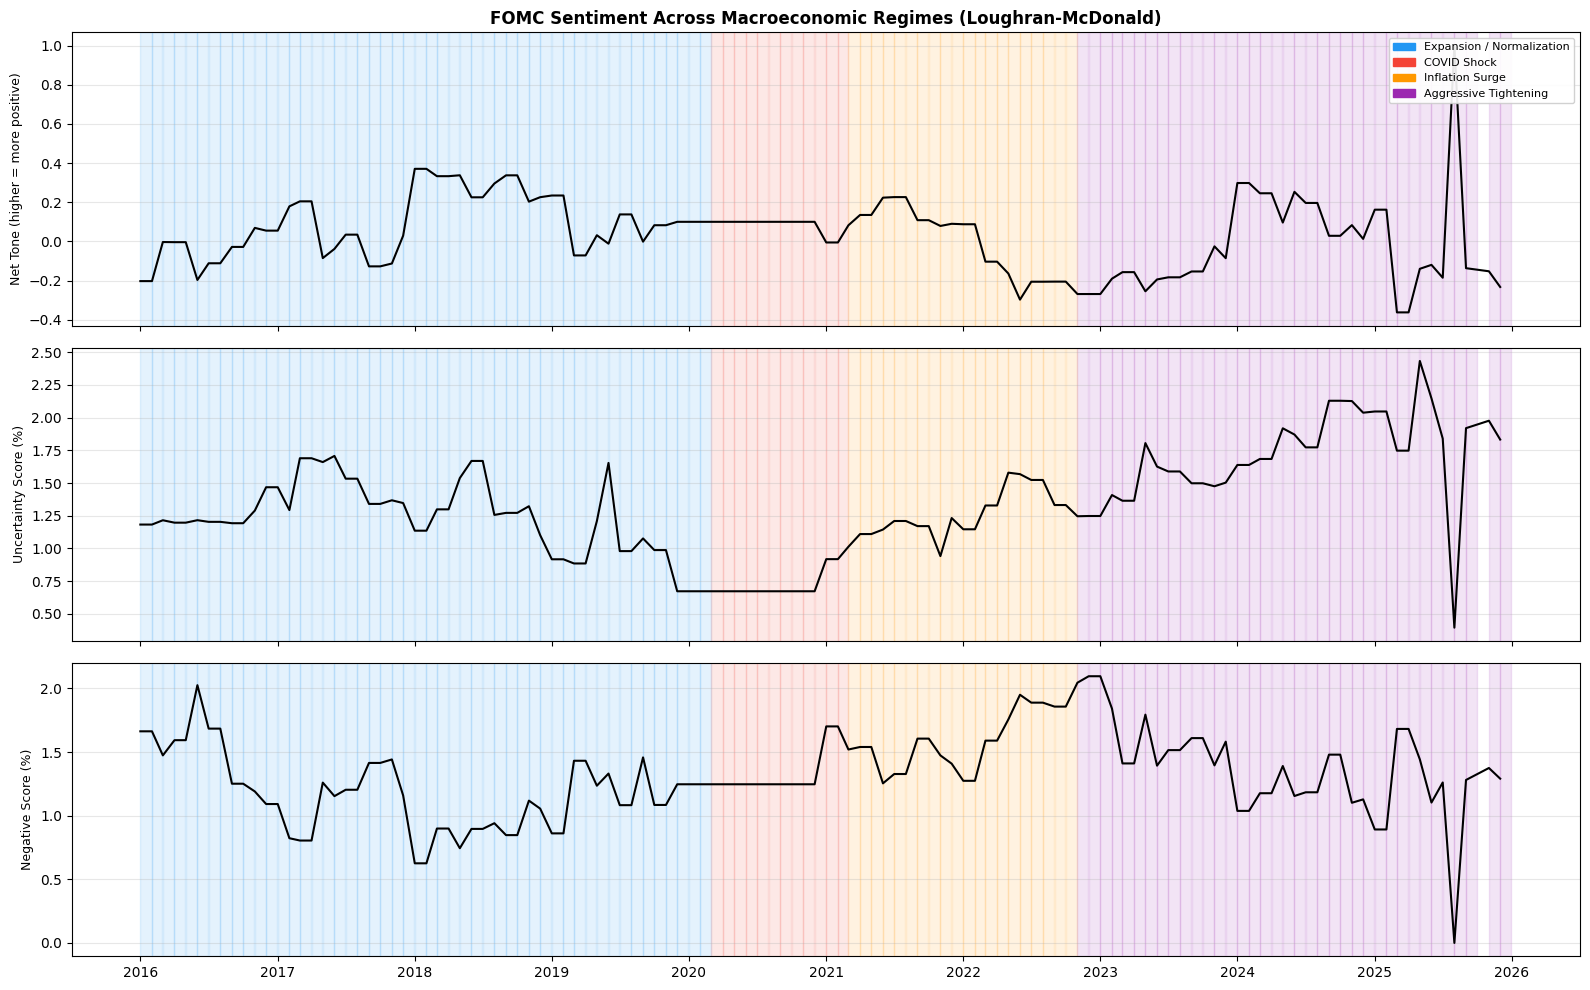

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

macro_path = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/macro_regimes_final.csv"
macro = pd.read_csv(macro_path, parse_dates=["observation_date"])
macro = macro.set_index("observation_date")

regime_colors = {
    "Expansion / Normalization": "#2196F3",
    "COVID Shock":               "#F44336",
    "Inflation Surge":           "#FF9800",
    "Aggressive Tightening":     "#9C27B0"
}

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

metrics = ["net_tone", "uncertainty_score", "negative_score"]
titles  = ["Net Tone (higher = more positive)",
           "Uncertainty Score (%)",
           "Negative Score (%)"]

for ax, metric, title in zip(axes, metrics, titles):
    for _, row in macro.iterrows():
        if row.name in sentiment_regime.index:
            color = regime_colors.get(row["regime_name"], "gray")
            ax.axvspan(row.name, row.name + pd.offsets.MonthEnd(1),
                       color=color, alpha=0.12)

    ax.plot(sentiment_regime.index, sentiment_regime[metric],
            color="black", linewidth=1.5)
    ax.set_ylabel(title, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_title(
    "FOMC Sentiment Across Macroeconomic Regimes (Loughran-McDonald)",
    fontsize=12, fontweight="bold"
)

patches = [mpatches.Patch(color=c, label=r)
           for r, c in regime_colors.items()]
axes[0].legend(handles=patches, loc="upper right",
               fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig("sentiment_regime_alignment_lm.png", dpi=150)
plt.show()

In [33]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import numpy as np

# ZiweiChen/FinBERT-FOMC (Chen et al., 2023)
# Fine-tuned on FOMC minutes 2006-2023 with Sentiment Focus relabeling
# Paper: https://doi.org/10.1145/3604237.3626843
model_name = "ZiweiChen/FinBERT-FOMC"

tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)
model.eval()

print("FinBERT-FOMC loaded successfully")
print(f"Labels: {model.config.id2label}")

# Quick sanity check with known sentences
from transformers import pipeline
test_pipe = pipeline("text-classification", model=model, tokenizer=tokenizer)

test_sentences = [
    "Inflation remained elevated and well above the Committee's target.",     # Hawkish (Positive)
    "Economic activity declined sharply and unemployment rose substantially.", # Dovish (Negative)
    "The Committee decided to maintain the target range."                      # Neutral
]

print("\nSanity check:")
for sent, result in zip(test_sentences, test_pipe(test_sentences)):
    print(f"  {result['label']:>10} ({result['score']:.3f})  {sent[:60]}...")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ZiweiChen/FinBERT-FOMC
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT-FOMC loaded successfully
Labels: {0: 'Neutral', 1: 'Positive', 2: 'Negative'}

Sanity check:
    Positive (0.984)  Inflation remained elevated and well above the Committee's t...
    Negative (0.994)  Economic activity declined sharply and unemployment rose sub...
     Neutral (0.992)  The Committee decided to maintain the target range....


In [36]:
device = torch.device("cpu")
model = model.to(device)

In [39]:
import re

def split_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s for s in sentences if len(s.split()) >= 5]


def score_sentences_finbert_fomc(sentences, tokenizer, model, batch_size=16):
    all_probs = []

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        # Force CPU
        inputs = {k: v.to("cpu") for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_probs)

In [40]:
fomc_path = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 3- Sentiment Analysis/fomc_cleaned.csv"
fomc_fb = pd.read_csv(fomc_path, parse_dates=["meeting_date"])

# Check label order from model config
label_map = model.config.id2label
print(f"Label mapping: {label_map}")
# Identify which index corresponds to which label
# Adjust indices below based on this output

results = []

for idx, row in fomc_fb.iterrows():
    sentences = split_sentences(row["text_clean"])

    if len(sentences) == 0:
        results.append({
            "hawkish_score": 0.0,
            "dovish_score": 0.0,
            "neutral_score": 0.0,
            "finbert_polarity": 0.0,
            "n_sentences": 0
        })
        continue

    probs = score_sentences_finbert_fomc(sentences, tokenizer, model)

    # Map labels to indices based on model.config.id2label
    # Common mapping for this model:
    #   0 = Positive (Hawkish), 1 = Negative (Dovish), 2 = Neutral
    # VERIFY with the label_map print above and sanity check
    label_to_idx = {v: k for k, v in label_map.items()}
    pos_idx = label_to_idx.get("Positive", label_to_idx.get("positive", 0))
    neg_idx = label_to_idx.get("Negative", label_to_idx.get("negative", 1))
    neu_idx = label_to_idx.get("Neutral", label_to_idx.get("neutral", 2))

    hawkish_mean = float(probs[:, pos_idx].mean())   # Positive = Hawkish
    dovish_mean  = float(probs[:, neg_idx].mean())    # Negative = Dovish
    neutral_mean = float(probs[:, neu_idx].mean())

    # FinBERT Polarity = Hawkish - Dovish
    finbert_polarity = hawkish_mean - dovish_mean

    results.append({
        "hawkish_score": round(hawkish_mean * 100, 4),
        "dovish_score": round(dovish_mean * 100, 4),
        "neutral_score": round(neutral_mean * 100, 4),
        "finbert_polarity": round(finbert_polarity, 4),
        "n_sentences": len(sentences)
    })

    if (idx + 1) % 20 == 0:
        print(f"Scored {idx + 1}/{len(fomc_fb)} documents")

scores_fb = pd.DataFrame(results)
fomc_fb = pd.concat([fomc_fb, scores_fb], axis=1)

print(f"\nFinBERT-FOMC scoring complete: {len(fomc_fb)} documents")
print(fomc_fb[["meeting_date", "doc_type", "hawkish_score",
               "dovish_score", "finbert_polarity"]].head(10))

Label mapping: {0: 'Neutral', 1: 'Positive', 2: 'Negative'}
Scored 20/146 documents
Scored 40/146 documents
Scored 60/146 documents
Scored 80/146 documents
Scored 100/146 documents
Scored 120/146 documents
Scored 140/146 documents

FinBERT-FOMC scoring complete: 146 documents
  meeting_date   doc_type  hawkish_score  dovish_score  finbert_polarity
0   2016-01-27    minutes        11.6297       25.2854           -0.1366
1   2016-01-27  statement        25.4810       17.4160            0.0806
2   2016-03-16    minutes        20.4119       38.2512           -0.1784
3   2016-03-16  statement        22.1541       19.9138            0.0224
4   2016-04-27    minutes        25.1972       35.6419           -0.1044
5   2016-04-27  statement        22.7907       19.3950            0.0340
6   2016-06-15    minutes        20.4738       37.1956           -0.1672
7   2016-06-15  statement        20.5637       20.7592           -0.0020
8   2016-07-27    minutes        22.9117       35.7611           -

In [41]:
fomc_fb["month"] = fomc_fb["meeting_date"].dt.to_period("M").dt.to_timestamp()

monthly_sentiment_fb = (
    fomc_fb
    .groupby("month")[
        ["hawkish_score", "dovish_score", "neutral_score", "finbert_polarity"]
    ]
    .mean()
    .round(4)
)

# Forward fill non-meeting months
monthly_sentiment_fb = (
    monthly_sentiment_fb
    .reindex(pd.date_range("2016-01-01", "2025-12-01", freq="MS"))
    .ffill()
)

monthly_sentiment_fb.index.name = "month"

print(f"Monthly FinBERT sentiment shape: {monthly_sentiment_fb.shape}")
print(f"Null counts:\n{monthly_sentiment_fb.isnull().sum()}")

Monthly FinBERT sentiment shape: (120, 4)
Null counts:
hawkish_score       0
dovish_score        0
neutral_score       0
finbert_polarity    0
dtype: int64


In [46]:
# Recalculate: drop the broken polarity, keep raw scores
monthly_sentiment_fb = monthly_sentiment_fb.drop(columns=["finbert_polarity"])

# Add a stress/concern index instead — this IS what the model captures
monthly_sentiment_fb["finbert_negative_ratio"] = (
    monthly_sentiment_fb["dovish_score"] /
    (monthly_sentiment_fb["hawkish_score"] + monthly_sentiment_fb["dovish_score"])
).round(4)

print(monthly_sentiment_fb.head(12))

            hawkish_score  dovish_score  neutral_score  finbert_negative_ratio
month                                                                         
2016-01-01        18.5554       21.3507        60.0940                  0.5350
2016-02-01        18.5554       21.3507        60.0940                  0.5350
2016-03-01        21.2830       29.0825        49.6345                  0.5774
2016-04-01        23.9939       27.5184        48.4876                  0.5342
2016-05-01        23.9939       27.5184        48.4876                  0.5342
2016-06-01        20.5188       28.9774        50.5038                  0.5854
2016-07-01        24.0495       27.2765        48.6740                  0.5314
2016-08-01        24.0495       27.2765        48.6740                  0.5314
2016-09-01        19.6903       23.0978        57.2118                  0.5398
2016-10-01        19.6903       23.0978        57.2118                  0.5398
2016-11-01        21.4278       23.7070        54.86

In [47]:
key_dates = {
    "2016-12-01": "Rate hike, calm conditions",
    "2020-03-01": "Emergency COVID cut",
    "2020-04-01": "Peak COVID shock",
    "2022-06-01": "75bp hike, inflation crisis",
    "2022-11-01": "Deep tightening",
    "2024-09-01": "First cut, cooling",
}

print(f"{'Date':<14} {'Event':<35} {'Neg Ratio':>10} {'Neutral':>10}")
print("-" * 72)

for d, event in key_dates.items():
    if d in monthly_sentiment_fb.index:
        row = monthly_sentiment_fb.loc[d]
        print(f"{d:<14} {event:<35} {row['finbert_negative_ratio']:>10.4f} "
              f"{row['neutral_score']:>10.1f}%")

Date           Event                                Neg Ratio    Neutral
------------------------------------------------------------------------
2016-12-01     Rate hike, calm conditions              0.4725       53.6%
2020-03-01     Emergency COVID cut                     0.5336       60.5%
2020-04-01     Peak COVID shock                        0.5336       60.5%
2022-06-01     75bp hike, inflation crisis             0.6236       57.1%
2022-11-01     Deep tightening                         0.6604       57.7%
2024-09-01     First cut, cooling                      0.6577       63.6%


In [48]:
macro_path = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/macro_regimes_final.csv"
macro = pd.read_csv(macro_path, parse_dates=["observation_date"])
macro = macro.set_index("observation_date")

sentiment_regime_fb = monthly_sentiment_fb.merge(
    macro[["regime", "regime_name"]],
    left_index=True, right_index=True,
    how="inner"
)

regime_order = [
    "Expansion / Normalization",
    "COVID Shock",
    "Inflation Surge",
    "Aggressive Tightening"
]

print("=" * 65)
print("FinBERT-FOMC Scores by Macroeconomic Regime")
print("(Reframed: model captures economic stress, not policy stance)")
print("=" * 65)

for r in regime_order:
    subset = sentiment_regime_fb[sentiment_regime_fb["regime_name"] == r]
    print(f"\n{r} (n={len(subset)} months)")
    print(f"  Negative Ratio:  {float(subset['finbert_negative_ratio'].mean()):>7.4f}  "
          f"(std: {float(subset['finbert_negative_ratio'].std()):.4f})")
    print(f"  Hawkish (Pos):   {float(subset['hawkish_score'].mean()):>7.4f}  "
          f"(std: {float(subset['hawkish_score'].std()):.4f})")
    print(f"  Dovish (Neg):    {float(subset['dovish_score'].mean()):>7.4f}  "
          f"(std: {float(subset['dovish_score'].std()):.4f})")
    print(f"  Neutral:         {float(subset['neutral_score'].mean()):>7.4f}  "
          f"(std: {float(subset['neutral_score'].std()):.4f})")

print("=" * 65)

FinBERT-FOMC Scores by Macroeconomic Regime
(Reframed: model captures economic stress, not policy stance)

Expansion / Normalization (n=50 months)
  Negative Ratio:   0.5024  (std: 0.0807)
  Hawkish (Pos):   20.6650  (std: 3.6520)
  Dovish (Neg):    21.0320  (std: 4.7740)
  Neutral:         58.3030  (std: 5.6866)

COVID Shock (n=12 months)
  Negative Ratio:   0.5241  (std: 0.0222)
  Hawkish (Pos):   18.9697  (std: 1.2758)
  Dovish (Neg):    20.8559  (std: 0.5113)
  Neutral:         60.1744  (std: 0.7646)

Inflation Surge (n=20 months)
  Negative Ratio:   0.5069  (std: 0.1086)
  Hawkish (Pos):   21.0333  (std: 5.0723)
  Dovish (Neg):    21.6421  (std: 5.1511)
  Neutral:         57.3246  (std: 3.4592)

Aggressive Tightening (n=37 months)
  Negative Ratio:   0.5626  (std: 0.1065)
  Hawkish (Pos):   15.9944  (std: 3.9214)
  Dovish (Neg):    21.1381  (std: 4.8061)
  Neutral:         62.8675  (std: 6.0527)


LM Net Tone vs FinBERT Negative Ratio by Regime
Regime                          LM Net Tone  FB Neg Ratio
------------------------------------------------------------
Expansion / Normalization           +0.0836        0.5024
COVID Shock                         +0.0828        0.5241
Inflation Surge                     +0.0053        0.5069
Aggressive Tightening               -0.0248        0.5626

Pearson r:  -0.7035  (p=0.0000)
Spearman r: -0.6679  (p=0.0000)
Expected: negative correlation (LM positive tone ↔ lower stress)


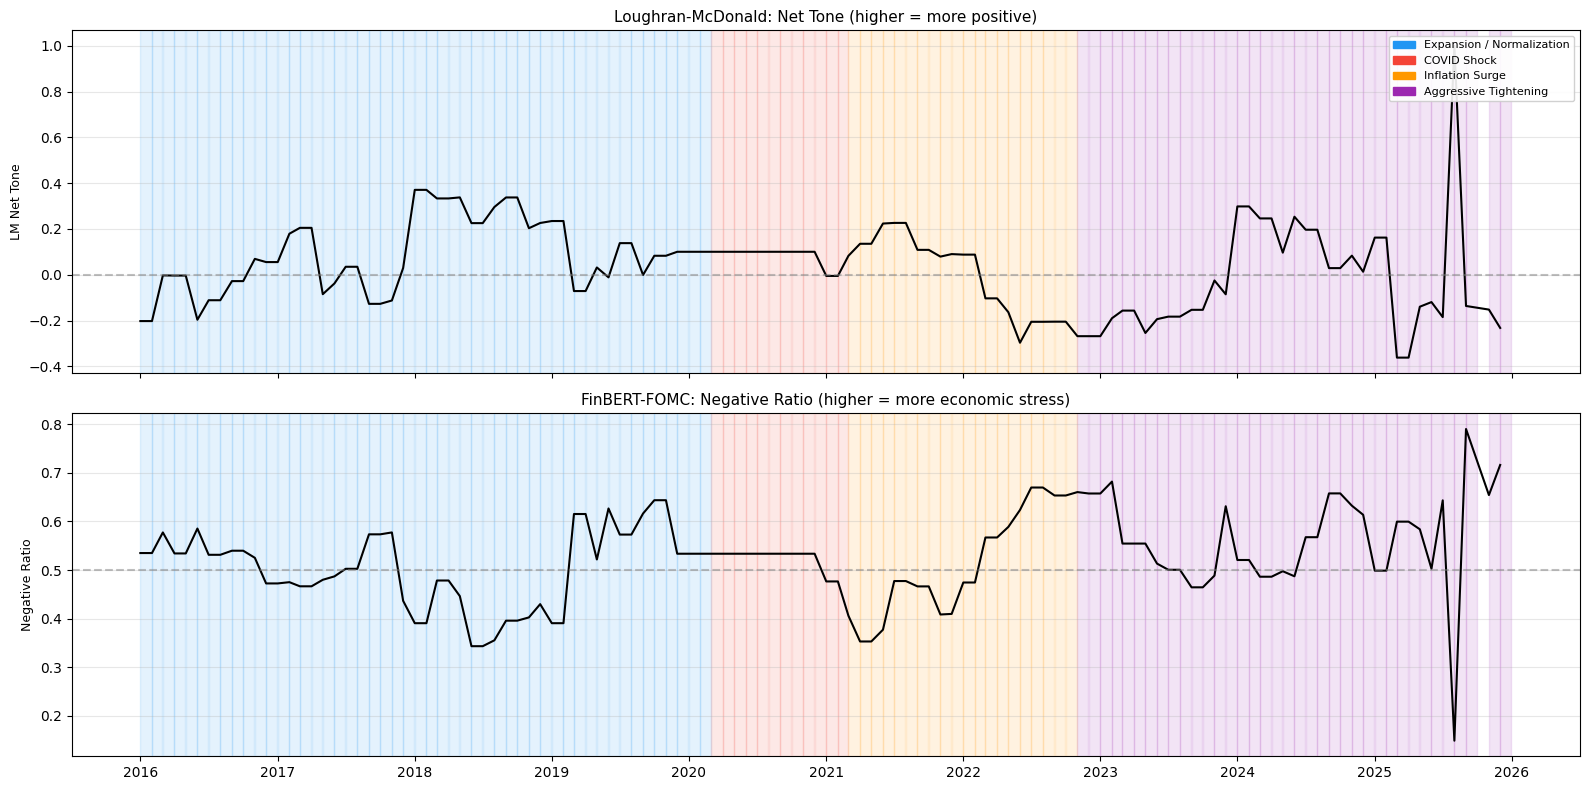

In [54]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Reload LM
lm_path = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 3- Sentiment Analysis/monthly_sentiment_lm.csv"
monthly_sentiment_lm = pd.read_csv(lm_path, parse_dates=["month"], index_col="month")
monthly_sentiment_lm = monthly_sentiment_lm.loc[:, ~monthly_sentiment_lm.columns.duplicated()]

sentiment_regime_lm = monthly_sentiment_lm.merge(
    macro[["regime", "regime_name"]],
    left_index=True, right_index=True,
    how="inner"
)

# Comparison table
print("=" * 80)
print("LM Net Tone vs FinBERT Negative Ratio by Regime")
print("=" * 80)
print(f"{'Regime':<30} {'LM Net Tone':>12} {'FB Neg Ratio':>13}")
print("-" * 60)

for r in regime_order:
    lm_val = float(sentiment_regime_lm[sentiment_regime_lm["regime_name"] == r]["net_tone"].mean())
    fb_val = float(sentiment_regime_fb[sentiment_regime_fb["regime_name"] == r]["finbert_negative_ratio"].mean())
    print(f"{r:<30} {lm_val:>+12.4f} {fb_val:>13.4f}")

print("=" * 80)

# Correlation
from scipy.stats import pearsonr, spearmanr

combined = monthly_sentiment_lm[["net_tone"]].merge(
    monthly_sentiment_fb[["finbert_negative_ratio"]],
    left_index=True, right_index=True,
    how="inner"
)

pearson_r, pearson_p   = pearsonr(combined["net_tone"], combined["finbert_negative_ratio"])
spearman_r, spearman_p = spearmanr(combined["net_tone"], combined["finbert_negative_ratio"])

print(f"\nPearson r:  {pearson_r:.4f}  (p={pearson_p:.4f})")
print(f"Spearman r: {spearman_r:.4f}  (p={spearman_p:.4f})")
print("Expected: negative correlation (LM positive tone ↔ lower stress)")

# Visual
regime_colors = {
    "Expansion / Normalization": "#2196F3",
    "COVID Shock":               "#F44336",
    "Inflation Surge":           "#FF9800",
    "Aggressive Tightening":     "#9C27B0"
}

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for _, row in macro.iterrows():
    if row.name in sentiment_regime_lm.index:
        color = regime_colors.get(row["regime_name"], "gray")
        axes[0].axvspan(row.name, row.name + pd.offsets.MonthEnd(1),
                        color=color, alpha=0.12)
        axes[1].axvspan(row.name, row.name + pd.offsets.MonthEnd(1),
                        color=color, alpha=0.12)

axes[0].plot(sentiment_regime_lm.index, sentiment_regime_lm["net_tone"],
             color="black", linewidth=1.5)
axes[0].set_ylabel("LM Net Tone", fontsize=9)
axes[0].set_title("Loughran-McDonald: Net Tone (higher = more positive)", fontsize=11)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(sentiment_regime_fb.index, sentiment_regime_fb["finbert_negative_ratio"],
             color="black", linewidth=1.5)
axes[1].set_ylabel("Negative Ratio", fontsize=9)
axes[1].set_title("FinBERT-FOMC: Negative Ratio (higher = more economic stress)", fontsize=11)
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[1].grid(axis="y", alpha=0.3)

patches = [mpatches.Patch(color=c, label=r)
           for r, c in regime_colors.items()]
axes[0].legend(handles=patches, loc="upper right", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig("lm_vs_finbert_comparison.png", dpi=150)
plt.show()

In [55]:
fomc_fb_out = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 3- Sentiment Analysis/fomc_scored_finbert.csv"
sentiment_fb_out = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 3- Sentiment Analysis/monthly_sentiment_finbert.csv"

fomc_fb.to_csv(fomc_fb_out, index=False)
monthly_sentiment_fb.to_csv(sentiment_fb_out)

print("Saved updated FinBERT outputs")

Saved updated FinBERT outputs
